In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

# Load Dataset and Check

In [2]:
df = pd.read_csv("../data/raw/sell_prices.csv")
df.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [3]:
df.columns.tolist()

['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 318.1 MB


In [5]:
df.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


# Unique Counts

In [6]:
print("Unique Stores:", df["store_id"].nunique())
print("Unique Items:", df["item_id"].nunique())
print("Unique Weeks:", df["wm_yr_wk"].nunique())


Unique Stores: 10
Unique Items: 3049
Unique Weeks: 282


# Price Distribution

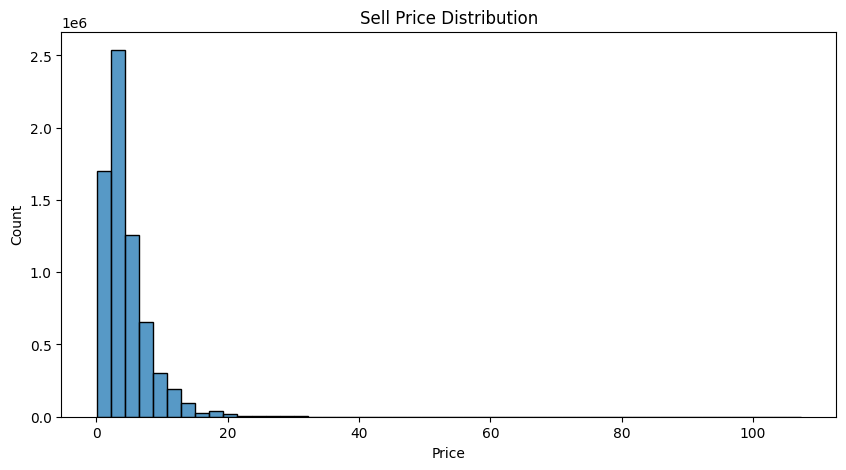

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df["sell_price"], bins=50)

plt.title("Sell Price Distribution")
plt.xlabel("Price")
plt.show()

# Highest Priced Items

In [8]:
highest_priced = df.sort_values(
    by="sell_price",
    ascending=False
)

highest_priced[[
    "item_id",
    "store_id",
    "sell_price"
]].head(20)


,item_id,store_id,sell_price
6485947,HOUSEHOLD_2_406,WI_3,107.32
6485945,HOUSEHOLD_2_406,WI_3,107.32
6485946,HOUSEHOLD_2_406,WI_3,107.32
5805276,HOUSEHOLD_2_406,WI_2,61.46
5805279,HOUSEHOLD_2_406,WI_2,61.46
5805278,HOUSEHOLD_2_406,WI_2,61.46
5805277,HOUSEHOLD_2_406,WI_2,61.46
5805283,HOUSEHOLD_2_406,WI_2,61.46
5805280,HOUSEHOLD_2_406,WI_2,61.46
5805281,HOUSEHOLD_2_406,WI_2,61.46


# Average Price Per Item

In [9]:
avg_price_per_item = (
    df.groupby("item_id")["sell_price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_per_item.head(10))

item_id
HOUSEHOLD_1_060    29.944663
HOBBIES_1_225      29.667422
HOBBIES_1_361      29.663117
HOBBIES_1_060      29.662547
HOBBIES_1_410      28.573242
HOBBIES_1_393      28.505718
HOUSEHOLD_2_446    25.474211
HOBBIES_1_104      23.931997
HOBBIES_1_354      23.156368
HOUSEHOLD_1_378    22.703127
Name: sell_price, dtype: float64


# Visualize Top Expensive Items

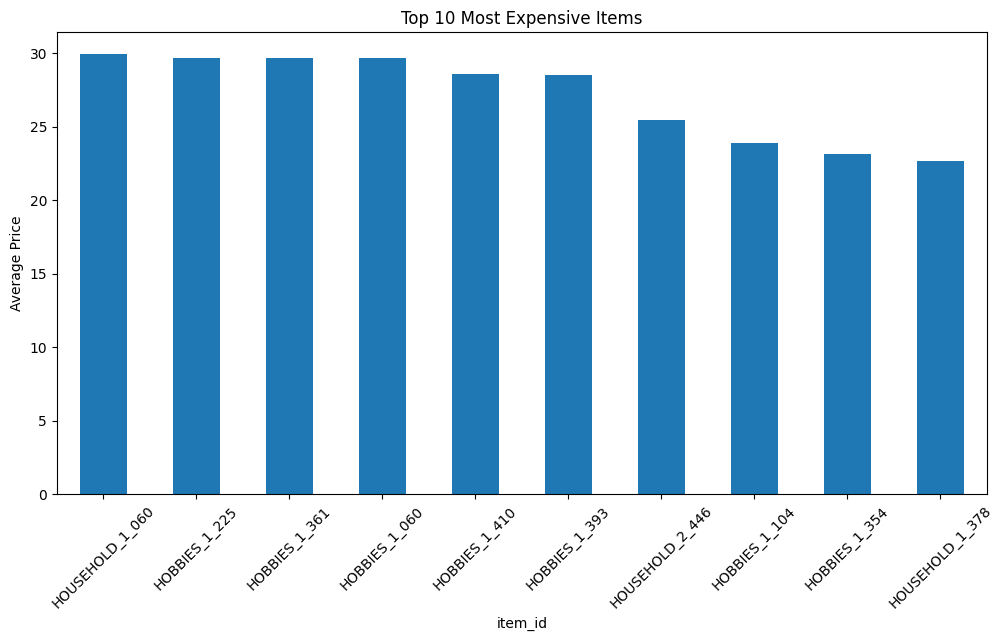

In [10]:
top_expensive = avg_price_per_item.head(10)

plt.figure(figsize=(12,6))

top_expensive.plot(kind="bar")

plt.title("Top 10 Most Expensive Items")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.show()

# Average Price Per Store

In [11]:
avg_store_price = (
    df.groupby("store_id")["sell_price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_store_price)

store_id
WI_1    4.457712
CA_2    4.445500
WI_2    4.441717
CA_4    4.421580
WI_3    4.418117
CA_1    4.414233
CA_3    4.388229
TX_3    4.387365
TX_1    4.374569
TX_2    4.366766
Name: sell_price, dtype: float64


# Price changes per SKUs

In [12]:
price_changes = (
    df.groupby(["store_id", "item_id"])["sell_price"]
    .nunique()
    .sort_values(ascending=False)
)

print(price_changes.head(20))

store_id  item_id    
TX_3      FOODS_1_095    21
TX_1      FOODS_1_095    21
WI_1      FOODS_1_129    20
CA_2      FOODS_1_095    18
WI_3      FOODS_1_129    18
TX_2      FOODS_1_095    18
CA_4      FOODS_1_095    18
CA_1      FOODS_1_095    18
WI_2      FOODS_1_129    18
WI_3      FOODS_1_096    17
TX_1      FOODS_1_096    17
          FOODS_1_129    17
WI_2      FOODS_1_096    17
TX_3      FOODS_1_096    17
WI_1      FOODS_1_076    17
          FOODS_1_096    17
WI_2      FOODS_1_076    16
CA_2      FOODS_1_096    16
WI_2      FOODS_1_053    16
TX_3      FOODS_1_129    16
Name: sell_price, dtype: int64


In [13]:
most_dynamic_prices = price_changes.reset_index()

most_dynamic_prices.columns = [
    "store_id",
    "item_id",
    "unique_price_count"
]

most_dynamic_prices.head(20)

,store_id,item_id,unique_price_count
0,TX_3,FOODS_1_095,21
1,TX_1,FOODS_1_095,21
2,WI_1,FOODS_1_129,20
3,CA_2,FOODS_1_095,18
4,WI_3,FOODS_1_129,18
5,TX_2,FOODS_1_095,18
6,CA_4,FOODS_1_095,18
7,CA_1,FOODS_1_095,18
8,WI_2,FOODS_1_129,18
9,WI_3,FOODS_1_096,17


In [15]:
sample_item = df["item_id"].iloc[0]

sample_df = df[df["item_id"] == sample_item]

sample_df = sample_df.sort_values("wm_yr_wk")

sample_df.head()


,store_id,item_id,wm_yr_wk,sell_price
2029797,CA_4,HOBBIES_1_001,11325,9.58
0,CA_1,HOBBIES_1_001,11325,9.58
2708822,TX_1,HOBBIES_1_001,11325,9.58
4800944,WI_1,HOBBIES_1_001,11325,9.58
4800945,WI_1,HOBBIES_1_001,11326,9.58


# Price Movement

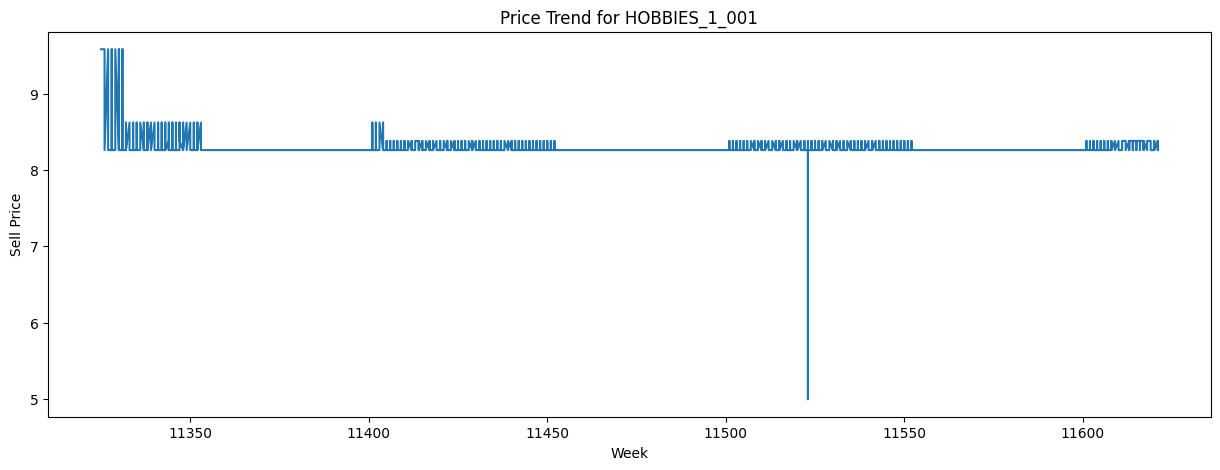

In [16]:
plt.figure(figsize=(15,5))

plt.plot(
    sample_df["wm_yr_wk"],
    sample_df["sell_price"]
)

plt.title(f"Price Trend for {sample_item}")

plt.xlabel("Week")
plt.ylabel("Sell Price")

plt.show()